# Chapter 14: Causal Trees & Causal Forests

## Case Study

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import causalml
from causalml.metrics import plot_gain, plot_qini, qini_score
from causalml.dataset import synthetic_data
from causalml.inference.tree import plot_dist_tree_leaves_values, get_tree_leaves_mask
from causalml.inference.tree import CausalRandomForestRegressor, CausalTreeRegressor
from causalml.inference.tree.utils import timeit
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore", message=".*force_all_finite.*")
np.random.seed(40)

y, X, T, tau, b, e = synthetic_data(mode=1, n=5000, p=5, sigma=1)
df = pd.DataFrame(X, columns=[f"x{i+1}" for i in range(X.shape[1])])
df["Y"] = y
df["T"] = T
df['treatment_effect'] = tau
feature_names = ['x1','x2','x3','x4','x5']
df.head()

,x1,x2,x3,x4,x5,Y,T,treatment_effect
0,0.407687,0.055366,0.788535,0.287305,0.450351,0.683611,0,0.231527
1,0.303912,0.526400,0.623812,0.776775,0.686242,3.326953,1,0.415156
2,0.980939,0.600816,0.813969,0.708645,0.027535,2.338263,1,0.790877
3,0.904267,0.449905,0.118925,0.835300,0.202248,3.137338,1,0.677086
4,0.174203,0.449147,0.669795,0.957399,0.833333,-0.652869,1,0.311675


In [2]:
df['T'].value_counts()

T
1    2647
0    2353
Name: count, dtype: int64

In [3]:
# Split data to training and testing samples for model validation
df_train, df_test = train_test_split(df, test_size=0.2, random_state=111)
n_train, n_test = df_train.shape[0], df_test.shape[0]

X_train, y_train = df_train[feature_names], df_train['Y'].values
X_test, y_test = df_test[feature_names], df_test['Y'].values
treatment_train, treatment_test = df_train['T'].values, df_test['T'].values
effect_test = df_test['T'].values

#observation = X_test.loc[[0]]

### CausalTreeRegressor

In [4]:
ctree = CausalTreeRegressor()
ctree.fit(X=X_train.values, y=y_train, treatment=treatment_train)

CausalTreeRegressor()

### CausalRandomForestRegressor

In [5]:
crforest = CausalRandomForestRegressor(criterion="causal_mse",
                                  min_samples_leaf=200,
                                  control_name=0,
                                  n_estimators=50)
crforest.fit(X=X_train, y=y_train, treatment=treatment_train)

CausalRandomForestRegressor(min_samples_leaf=200, n_estimators=50)

### Impurity-based feature importance

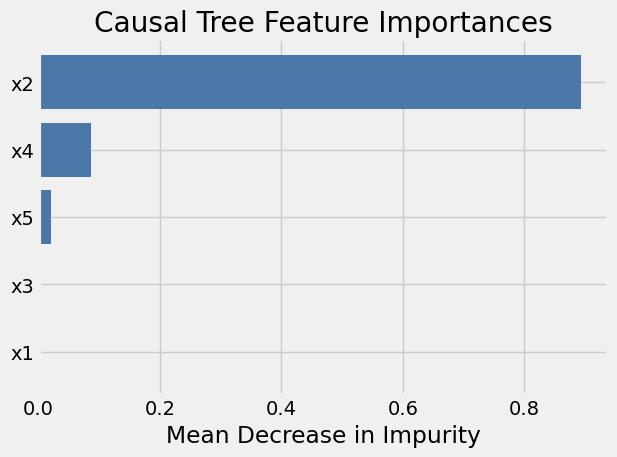

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_importances = pd.DataFrame({
    'tree': ctree.feature_importances_,
    'forest': crforest.feature_importances_,
    'feature': feature_names
})

# Feature names
df_importances = df_importances.set_index('feature')

# Causal Tree
tree_sorted = df_importances['tree'].sort_values(ascending=False)
fig, ax = plt.subplots()
ax.barh(tree_sorted.index, tree_sorted.values, color="#4C78A8")
ax.set_title("Causal Tree Feature Importances")
ax.set_xlabel("Mean Decrease in Impurity")  
ax.set_ylabel("")                         
ax.invert_yaxis()                   
plt.tight_layout()
plt.show()

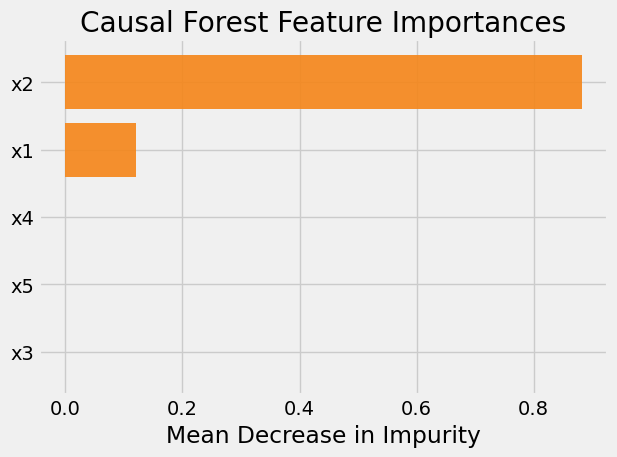

In [7]:
# Causal Forest
forest_imp = df_importances['forest']
forest_order = forest_imp.sort_values(ascending=False).index
forest_sorted = forest_imp.loc[forest_order]

fig, ax = plt.subplots()
# Horizontal bars => use xerr (not yerr) for error bars
ax.barh(forest_sorted.index,
        forest_sorted.values,
        color="#F58518",
        ecolor="gray",
        alpha=0.9)
ax.set_title("Causal Forest Feature Importances")
ax.set_xlabel("Mean Decrease in Impurity")
ax.set_ylabel("")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### SHAP

In [8]:
tree_explainer = shap.TreeExplainer(ctree)
# Expected values for treatment=0 and treatment=1. i.e. Y|X,T=0 and Y|X,T=1
tree_explainer.expected_value

array([1.03180274, 1.97115456])

In [9]:
shap_values = tree_explainer.shap_values(X_test)

In [10]:
observation = X_test.iloc[0,:]

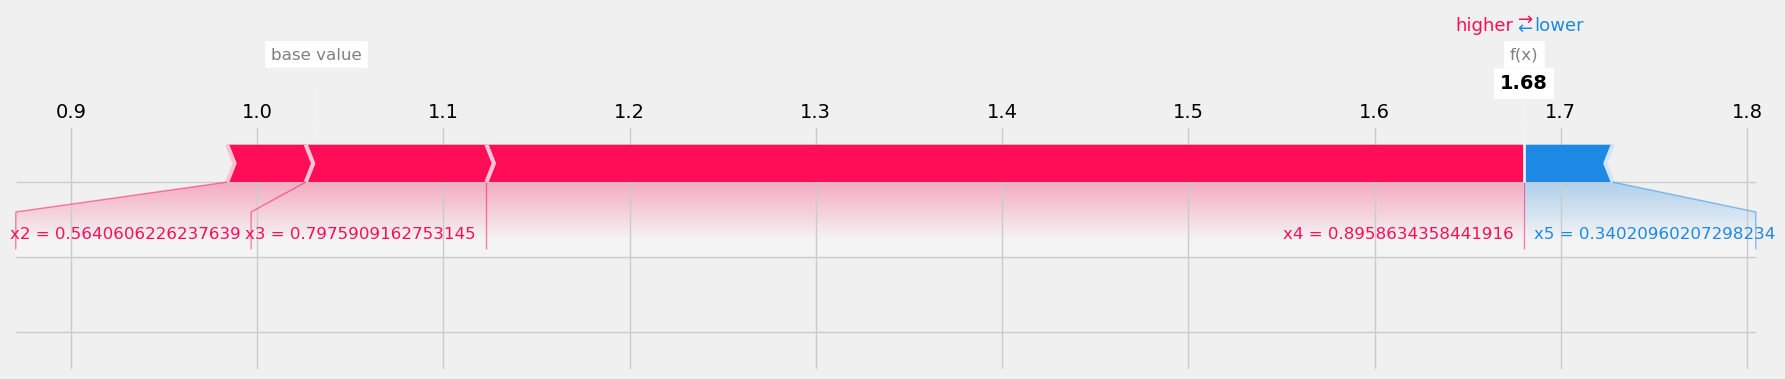

In [11]:
shap.initjs()
treatment_idx = 0
shap_values = tree_explainer.shap_values(observation)
shap.force_plot(
    base_value=np.array([tree_explainer.expected_value[treatment_idx]]),
    shap_values=shap_values[ :, treatment_idx],
    features=observation,
    matplotlib=True
)